# Problem Statement

## Title:
###  Travel Package Price and Destination Analysis from TravelTriangle

## Problem Statement:

Travel Package Price and Destination Analysis from TravelTriangle
The objective of this project is to analyze travel tour packages to understand the factors affecting package revenue (Price).
We aim to explore how duration (Days/Nights), discounts, destination and other features influence the revenue generated by travel packages.

In [1]:
# importing Libraries

import numpy as np
import pandas as pd
import requests
import warnings
warnings.filterwarnings('ignore')
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests
import numpy as np
import time

In [2]:
package = []
stay = []
cities = []
category = []
price = []
discount_percent = []
pagenum = []
original_price = []


total_time = time.time()

for i in range(1, 62):

    start_time = time.time()

    URL = f"https://traveltriangle.com/tour-packages/kerala?page={i}"
    page = requests.get(URL)
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', class_='col-12 p8 pt0'):

        name_tag = x.find('p', class_="col-md-12 pl0 fw9 m0 f16 pfc3 at_packageName")
        stay_tag = x.find('span', class_='iblock sfc6')
        location_tag = x.find('ul', class_='clearfix package-cities-list at_packagecity_list')
        discount_tag = x.find('span', class_='f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label')
        price_tag = x.find('p', class_='sfc3 m0 f20 fw9 priceVal at_newprice')
        old_price_tag = x.find('p', class_='sfc6 m0 f14 at_oldprice')
        tags_tag = x.find('ul', class_='package-tags at_package_tags')

        # Basic details
        package.append(name_tag.text.strip() if name_tag else np.nan)
        stay.append(stay_tag.text.strip() if stay_tag else np.nan)
        price.append(price_tag.text.strip() if price_tag else np.nan)
        original_price.append(old_price_tag.text.strip() if old_price_tag else np.nan)
        discount_percent.append(discount_tag.text.strip() if discount_tag else np.nan)
        pagenum.append(i)

        # Cities extraction (fixed)
        if location_tag:
            city_list = [li.text.strip() for li in location_tag.find_all("li")]
        else:
            city_list = []

        cities.append(city_list)

        # Extract package tags
        if tags_tag:
            tags = [li.text.strip() for li in tags_tag.find_all("li")]
        else:
            tags = []

        category.append(tags)

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 6.72 seconds
Page 2 completed in 7.51 seconds
Page 3 completed in 6.83 seconds
Page 4 completed in 5.95 seconds
Page 5 completed in 6.44 seconds
Page 6 completed in 8.20 seconds
Page 7 completed in 5.63 seconds
Page 8 completed in 7.41 seconds
Page 9 completed in 7.34 seconds
Page 10 completed in 6.64 seconds
Page 11 completed in 10.76 seconds
Page 12 completed in 7.71 seconds
Page 13 completed in 6.04 seconds
Page 14 completed in 7.88 seconds
Page 15 completed in 7.76 seconds
Page 16 completed in 10.52 seconds
Page 17 completed in 8.83 seconds
Page 18 completed in 6.00 seconds
Page 19 completed in 7.94 seconds
Page 20 completed in 8.86 seconds
Page 21 completed in 7.52 seconds
Page 22 completed in 12.29 seconds
Page 23 completed in 8.60 seconds
Page 24 completed in 6.88 seconds
Page 25 completed in 7.88 seconds
Page 26 completed in 7.51 seconds
Page 27 completed in 9.71 seconds
Page 28 completed in 6.29 seconds
Page 29 completed in 6.62 seconds
Page 30 completed in

In [3]:
len(package)
len(original_price)
len(cities)

1220

In [4]:
df = pd.DataFrame({
    "Name": package,
    "Location": cities,
    "Stay": stay,
    "Packages": category,
    "Price": price,
    "Discount": discount_percent,
    "OriginalPrice":original_price
    
})

In [5]:
df

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice
0,Alleppey-Munnar Kerala Weekend Tour,"[Munnar (2D), Alleppey (2D)]",4 Days & 3 Nights,"[Spice Plantations, Hill station, Houseboat St...","â¹ 13,020/-â¹ 17,132/-",24% Off,NaN
1,Charismatic Kochi Tour Package,"[Kochi (1D), Munnar (3D)]",4 Days & 3 Nights,"[Waterfalls, Adventure, Nature, Shopping, Wild...","â¹ 15,000/-â¹ 16,484/-",9% Off,NaN
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"[Munnar (2D), Thekkady (1D), Alleppey (1D), Ko...",6 Days & 5 Nights,"[Periyar Wildlife Sanctuary, Cruises, Eravikul...","â¹ 22,000/-â¹ 24,444/-",10% Off,NaN
3,Vibrant Kochi Munnar Honeymoon Tour Package,"[Cochin (1D), Munnar (3D)]",4 Days & 3 Nights,"[Scenic views, Adventure, Tea gardens, Hill st...","â¹ 14,571/-â¹ 16,190/-",10% Off,NaN
4,Mesmerizing Getaway To Kochi,[Kochi (2D)],2 Days & 1 Nights,"[Scenery, landscape, Sightseeing, Leisure Time...","â¹ 4,800/-â¹ 5,275/-",9% Off,NaN
...,...,...,...,...,...,...,...
1215,Ecstatic Athirapally Tour Package,"[Athirapally (2D), Munnar (2D), Alleppey (1D),...",8 Days & 7 Nights,"[Athirapally waterfalls, Nature, Munnar, Hill ...","â¹ 28,123/-â¹ 30,904/-",9% Off,NaN
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"[Munnar (2D), Thekkady (2D)]",4 Days & 3 Nights,"[Hills, Adventure, Jungle Safari, Nature, Wild...","â¹ 13,167/-â¹ 18,434/-",29% Off,NaN
1217,Captivating Thekkady Honeymoon Package,"[Kumarakom (1D), Thekkady (1D), Munnar (3D)]",5 Days & 4 Nights,"[Ideal for Couples, Water Activities, Adventur...","â¹ 15,624/-â¹ 17,360/-",10% Off,NaN
1218,A Surreal Escape To Mesmerising Destinations,"[Munnar (2D), Alleppey (2D)]",4 Days & 3 Nights,"[Romantic, Hill station, Hills, Cruises, Water...","â¹ 12,880/-â¹ 16,269/-",21% Off,NaN


In [6]:
df.to_csv("travel.csv",index=False)

In [7]:
df=pd.read_csv("travel.csv")

In [8]:
df

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...","â¹ 13,020/-â¹ 17,132/-",24% Off,NaN
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...","â¹ 15,000/-â¹ 16,484/-",9% Off,NaN
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...","â¹ 22,000/-â¹ 24,444/-",10% Off,NaN
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...","â¹ 14,571/-â¹ 16,190/-",10% Off,NaN
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...","â¹ 4,800/-â¹ 5,275/-",9% Off,NaN
...,...,...,...,...,...,...,...
1215,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...","â¹ 28,123/-â¹ 30,904/-",9% Off,NaN
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"['Munnar (2D)', 'Thekkady (2D)']",4 Days & 3 Nights,"['Hills', 'Adventure', 'Jungle Safari', 'Natur...","â¹ 13,167/-â¹ 18,434/-",29% Off,NaN
1217,Captivating Thekkady Honeymoon Package,"['Kumarakom (1D)', 'Thekkady (1D)', 'Munnar (3...",5 Days & 4 Nights,"['Ideal for Couples', 'Water Activities', 'Adv...","â¹ 15,624/-â¹ 17,360/-",10% Off,NaN
1218,A Surreal Escape To Mesmerising Destinations,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Romantic', 'Hill station', 'Hills', 'Cruises...","â¹ 12,880/-â¹ 16,269/-",21% Off,NaN


## Data Cleaning

In [9]:
df.head()

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...","â¹ 13,020/-â¹ 17,132/-",24% Off,NaN
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...","â¹ 15,000/-â¹ 16,484/-",9% Off,NaN
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...","â¹ 22,000/-â¹ 24,444/-",10% Off,NaN
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...","â¹ 14,571/-â¹ 16,190/-",10% Off,NaN
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...","â¹ 4,800/-â¹ 5,275/-",9% Off,NaN


In [10]:
df.tail()

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice
1215,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...","â¹ 28,123/-â¹ 30,904/-",9% Off,NaN
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"['Munnar (2D)', 'Thekkady (2D)']",4 Days & 3 Nights,"['Hills', 'Adventure', 'Jungle Safari', 'Natur...","â¹ 13,167/-â¹ 18,434/-",29% Off,NaN
1217,Captivating Thekkady Honeymoon Package,"['Kumarakom (1D)', 'Thekkady (1D)', 'Munnar (3...",5 Days & 4 Nights,"['Ideal for Couples', 'Water Activities', 'Adv...","â¹ 15,624/-â¹ 17,360/-",10% Off,NaN
1218,A Surreal Escape To Mesmerising Destinations,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Romantic', 'Hill station', 'Hills', 'Cruises...","â¹ 12,880/-â¹ 16,269/-",21% Off,NaN
1219,Visit Kerala And See Astounding Places,"['Munnar (1D)', 'Thekkady (1D)', 'Kochi (2D)']",4 Days & 3 Nights,"['Natural Beauty', 'Tea Garden', 'Spice Garden...","â¹ 11,760/-â¹ 13,213/-",11% Off,NaN


In [11]:
df.columns

Index(['Name', 'Location', 'Stay', 'Packages', 'Price', 'Discount',
       'OriginalPrice'],
      dtype='object')

In [12]:
df.shape # Finding no.of rows and columns

(1220, 7)

In [13]:
df.dtypes # finding dat types of column values

Name              object
Location          object
Stay              object
Packages          object
Price             object
Discount          object
OriginalPrice    float64
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           1220 non-null   object 
 1   Location       1220 non-null   object 
 2   Stay           1220 non-null   object 
 3   Packages       1220 non-null   object 
 4   Price          1220 non-null   object 
 5   Discount       1220 non-null   object 
 6   OriginalPrice  0 non-null      float64
dtypes: float64(1), object(6)
memory usage: 66.8+ KB


In [15]:
df.describe()

,OriginalPrice
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [16]:
df.describe(include="all")

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice
count,1220,1220,1220,1220,1220,1220,0.0
unique,20,16,6,20,19,11,NaN
top,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...","â¹ 15,000/-â¹ 16,484/-",9% Off,NaN
freq,61,183,488,61,122,427,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.isnull().sum() # checking columns have null values

Name                0
Location            0
Stay                0
Packages            0
Price               0
Discount            0
OriginalPrice    1220
dtype: int64

In [18]:
df["Price"]

0       â¹ 13,020/-â¹ 17,132/-
1       â¹ 15,000/-â¹ 16,484/-
2       â¹ 22,000/-â¹ 24,444/-
3       â¹ 14,571/-â¹ 16,190/-
4         â¹ 4,800/-â¹ 5,275/-
                  ...           
1215    â¹ 28,123/-â¹ 30,904/-
1216    â¹ 13,167/-â¹ 18,434/-
1217    â¹ 15,624/-â¹ 17,360/-
1218    â¹ 12,880/-â¹ 16,269/-
1219    â¹ 11,760/-â¹ 13,213/-
Name: Price, Length: 1220, dtype: object

In [19]:
# Extracting Original Price from Price

In [20]:
df["discounted_price"] = df["Price"].apply(
    lambda x: int(re.findall(r"[\d,]+", str(x))[0].replace(",", "")) if re.findall(r"[\d,]+", str(x)) else None
)

df["original_price"] = df["Price"].apply(
    lambda x: int(re.findall(r"[\d,]+", str(x))[1].replace(",", "")) if len(re.findall(r"[\d,]+", str(x))) > 1 else None
)

In [21]:
df["Price"]=df["discounted_price"]

In [22]:
df["Price"]

0       13020
1       15000
2       22000
3       14571
4        4800
        ...  
1215    28123
1216    13167
1217    15624
1218    12880
1219    11760
Name: Price, Length: 1220, dtype: int64

In [23]:
df["original_price"]

0       17132
1       16484
2       24444
3       16190
4        5275
        ...  
1215    30904
1216    18434
1217    17360
1218    16269
1219    13213
Name: original_price, Length: 1220, dtype: int64

In [24]:
df

,Name,Location,Stay,Packages,Price,Discount,OriginalPrice,discounted_price,original_price
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...",13020,24% Off,NaN,13020,17132
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...",15000,9% Off,NaN,15000,16484
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...",22000,10% Off,NaN,22000,24444
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...",14571,10% Off,NaN,14571,16190
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...",4800,9% Off,NaN,4800,5275
...,...,...,...,...,...,...,...,...,...
1215,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9% Off,NaN,28123,30904
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"['Munnar (2D)', 'Thekkady (2D)']",4 Days & 3 Nights,"['Hills', 'Adventure', 'Jungle Safari', 'Natur...",13167,29% Off,NaN,13167,18434
1217,Captivating Thekkady Honeymoon Package,"['Kumarakom (1D)', 'Thekkady (1D)', 'Munnar (3...",5 Days & 4 Nights,"['Ideal for Couples', 'Water Activities', 'Adv...",15624,10% Off,NaN,15624,17360
1218,A Surreal Escape To Mesmerising Destinations,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Romantic', 'Hill station', 'Hills', 'Cruises...",12880,21% Off,NaN,12880,16269


In [25]:
df.drop("OriginalPrice",axis=1, inplace=True)

In [26]:
df

,Name,Location,Stay,Packages,Price,Discount,discounted_price,original_price
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...",13020,24% Off,13020,17132
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...",15000,9% Off,15000,16484
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...",22000,10% Off,22000,24444
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...",14571,10% Off,14571,16190
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...",4800,9% Off,4800,5275
...,...,...,...,...,...,...,...,...
1215,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9% Off,28123,30904
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"['Munnar (2D)', 'Thekkady (2D)']",4 Days & 3 Nights,"['Hills', 'Adventure', 'Jungle Safari', 'Natur...",13167,29% Off,13167,18434
1217,Captivating Thekkady Honeymoon Package,"['Kumarakom (1D)', 'Thekkady (1D)', 'Munnar (3...",5 Days & 4 Nights,"['Ideal for Couples', 'Water Activities', 'Adv...",15624,10% Off,15624,17360
1218,A Surreal Escape To Mesmerising Destinations,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Romantic', 'Hill station', 'Hills', 'Cruises...",12880,21% Off,12880,16269


In [27]:
df.drop("discounted_price",axis=1, inplace=True)
df

,Name,Location,Stay,Packages,Price,Discount,original_price
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...",13020,24% Off,17132
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...",15000,9% Off,16484
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...",22000,10% Off,24444
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...",14571,10% Off,16190
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...",4800,9% Off,5275
...,...,...,...,...,...,...,...
1215,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9% Off,30904
1216,Mesmerizing Kerala Holiday: Weekend in Munnar ...,"['Munnar (2D)', 'Thekkady (2D)']",4 Days & 3 Nights,"['Hills', 'Adventure', 'Jungle Safari', 'Natur...",13167,29% Off,18434
1217,Captivating Thekkady Honeymoon Package,"['Kumarakom (1D)', 'Thekkady (1D)', 'Munnar (3...",5 Days & 4 Nights,"['Ideal for Couples', 'Water Activities', 'Adv...",15624,10% Off,17360
1218,A Surreal Escape To Mesmerising Destinations,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Romantic', 'Hill station', 'Hills', 'Cruises...",12880,21% Off,16269


In [28]:
# To remove off from discount
df["Discount"] = df["Discount"].apply(lambda x:re.findall(r"[\d%]+",x)[0])

In [29]:
# To remove % from discount
df["Discount"] = df["Discount"].str.replace("%", "", regex=False)

In [30]:
df["Discount"]

0       24
1        9
2       10
3       10
4        9
        ..
1215     9
1216    29
1217    10
1218    21
1219    11
Name: Discount, Length: 1220, dtype: object

In [31]:
df.isnull().sum()

Name              0
Location          0
Stay              0
Packages          0
Price             0
Discount          0
original_price    0
dtype: int64

In [32]:
df.columns

Index(['Name', 'Location', 'Stay', 'Packages', 'Price', 'Discount',
       'original_price'],
      dtype='object')

In [33]:
df.dtypes

Name              object
Location          object
Stay              object
Packages          object
Price              int64
Discount          object
original_price     int64
dtype: object

In [34]:
df["Discount"]=df["Discount"].astype("int")

In [35]:
df.dtypes

Name              object
Location          object
Stay              object
Packages          object
Price              int64
Discount           int32
original_price     int64
dtype: object

In [36]:
# Extracting Days from Stay
df["Days"] = df["Stay"].str.extract(r'(\d+)\s*Days')
df["Days"] = df["Days"].astype(int)

In [37]:
df["Days"]

0       4
1       4
2       6
3       4
4       2
       ..
1215    8
1216    4
1217    5
1218    4
1219    4
Name: Days, Length: 1220, dtype: int32

In [38]:
# Extracting Nights from Stay
df["Nights"] = df["Stay"].str.extract(r'(\d+)\s*Nights')
df["Nights"] = df["Nights"].astype(int)

In [39]:
df["Nights"]

0       3
1       3
2       5
3       3
4       1
       ..
1215    7
1216    3
1217    4
1218    3
1219    3
Name: Nights, Length: 1220, dtype: int32

In [40]:
df.columns

Index(['Name', 'Location', 'Stay', 'Packages', 'Price', 'Discount',
       'original_price', 'Days', 'Nights'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            1220 non-null   object
 1   Location        1220 non-null   object
 2   Stay            1220 non-null   object
 3   Packages        1220 non-null   object
 4   Price           1220 non-null   int64 
 5   Discount        1220 non-null   int32 
 6   original_price  1220 non-null   int64 
 7   Days            1220 non-null   int32 
 8   Nights          1220 non-null   int32 
dtypes: int32(3), int64(2), object(4)
memory usage: 71.6+ KB


In [42]:
df.shape

(1220, 9)

In [43]:
df.isnull().sum()

Name              0
Location          0
Stay              0
Packages          0
Price             0
Discount          0
original_price    0
Days              0
Nights            0
dtype: int64

In [44]:
df.to_csv("travel_data_cleaned.csv", index=False)

In [46]:
df.head()

,Name,Location,Stay,Packages,Price,Discount,original_price,Days,Nights
0,Alleppey-Munnar Kerala Weekend Tour,"['Munnar (2D)', 'Alleppey (2D)']",4 Days & 3 Nights,"['Spice Plantations', 'Hill station', 'Housebo...",13020,24,17132,4,3
1,Charismatic Kochi Tour Package,"['Kochi (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Waterfalls', 'Adventure', 'Nature', 'Shoppin...",15000,9,16484,4,3
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,"['Munnar (2D)', 'Thekkady (1D)', 'Alleppey (1D...",6 Days & 5 Nights,"['Periyar Wildlife Sanctuary', 'Cruises', 'Era...",22000,10,24444,6,5
3,Vibrant Kochi Munnar Honeymoon Tour Package,"['Cochin (1D)', 'Munnar (3D)']",4 Days & 3 Nights,"['Scenic views', 'Adventure', 'Tea gardens', '...",14571,10,16190,4,3
4,Mesmerizing Getaway To Kochi,['Kochi (2D)'],2 Days & 1 Nights,"['Scenery', 'landscape', 'Sightseeing', 'Leisu...",4800,9,5275,2,1


# Exploratory Data Analysis (EDA)

## 1.Univariate Analysis - Continuous Variables 
Analyzing one variable at a time

##### 1.1 Central Tendency & Dispersion (Statistical Metrics)

In [47]:
df.columns

Index(['Name', 'Location', 'Stay', 'Packages', 'Price', 'Discount',
       'original_price', 'Days', 'Nights'],
      dtype='object')

In [48]:
import pandas as pd

cont_vars = ['Price', 'Discount', 'original_price', 'Days', 'Nights']

# Central tendency
mean = df[cont_vars].mean()
median = df[cont_vars].median()
mode = df[cont_vars].mode().iloc[0]

# Dispersion
std = df[cont_vars].std()
variance = df[cont_vars].var()
range_vals = df[cont_vars].max() - df[cont_vars].min()
iqr = df[cont_vars].quantile(0.75) - df[cont_vars].quantile(0.25)

summary = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode,
    "Std Dev": std,
    "Variance": variance,
    "Range": range_vals,
    "IQR": iqr
})

print(summary)

                    Mean   Median   Mode      Std Dev      Variance  Range  \
Price           13987.20  13583.5  15000  6190.862925  3.832678e+07  23323   
Discount           13.50     10.0      9     6.854817  4.698852e+01     24   
original_price  16430.30  16376.5  16484  7522.633220  5.659001e+07  25629   
Days                4.15      4.0      4     1.388914  1.929081e+00      6   
Nights              3.15      3.0      3     1.388914  1.929081e+00      6   

                     IQR  
Price            7534.00  
Discount            9.25  
original_price  10123.25  
Days                2.00  
Nights              2.00  


In [49]:
df[cont_vars].describe()

,Price,Discount,original_price,Days,Nights
count,1220.000000,1220.000000,1220.00000,1220.000000,1220.000000
mean,13987.200000,13.500000,16430.30000,4.150000,3.150000
std,6190.862925,6.854817,7522.63322,1.388914,1.388914
min,4800.000000,5.000000,5275.00000,2.000000,1.000000
25%,8944.000000,9.000000,9813.25000,3.000000,2.000000
50%,13583.500000,10.000000,16376.50000,4.000000,3.000000
75%,16478.000000,18.250000,19936.50000,5.000000,4.000000
max,28123.000000,29.000000,30904.00000,8.000000,7.000000


#### 1.2. Histogram - Price Distribution

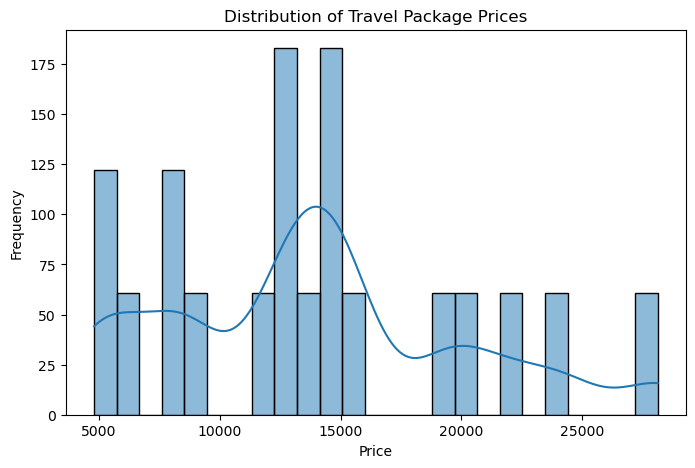

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=25, kde=True)

plt.title("Distribution of Travel Package Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##### Interpretation

Most tour packages are concentrated in the mid-price range i.e ₹12k-16k, while very low and very high-priced packages are fewer.The mean price is slightly higher than the median, suggesting a right-skewed distribution. Some high-price outliers (₹20,000+) indicate premium or long-duration trips.

##### Business Insight

Travel companies mainly offer mid-range packages i.e, ₹12k–₹16k to attract a larger number of customers while still maintaining profitability.

####  1.3 Price outliers(IQR + Boxplot)

##### 1.IQR Method to detect Outliers

In [51]:
# Convert price to numeric if needed
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Calculate IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]

print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 61


,Name,Location,Stay,Packages,Price,Discount,original_price,Days,Nights
15,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9,30904,8,7
35,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9,30904,8,7
55,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9,30904,8,7
75,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9,30904,8,7
95,Ecstatic Athirapally Tour Package,"['Athirapally (2D)', 'Munnar (2D)', 'Alleppey ...",8 Days & 7 Nights,"['Athirapally waterfalls', 'Nature', 'Munnar',...",28123,9,30904,8,7


##### 2.Boxplot to Visualize Outliers

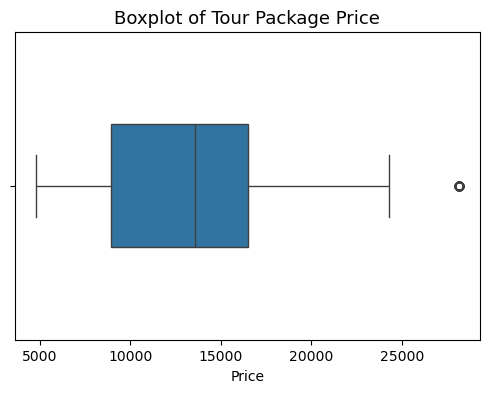

In [52]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["Price"],
    width=0.4,           # thinner box
    fliersize=6          # size of outlier point
)

plt.title("Boxplot of Tour Package Price", fontsize=13)
plt.xlabel("Price")

plt.show()

##### Interpretation
Some packages appear far above the upper whisker indicating outliers (luxury packages)..


##### Business Insights
Travel companies mainly offer mid-range packages, which likely attract most customers. The higher-priced outlier suggests a niche market for luxury or premium tour packages

#### 1.4 Violin Plot - Discount Distribution

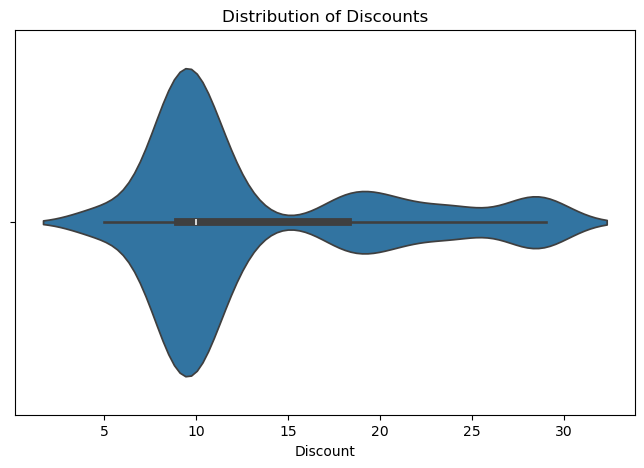

In [53]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df['Discount'])

plt.title("Distribution of Discounts")
plt.show()

##### Interpretation
Discounts are concentrated around 8–12%.

##### Business Insight
Companies prefer moderate discounts rather than extreme offers.

#### 1.5 Bar PLot - Stay Duration

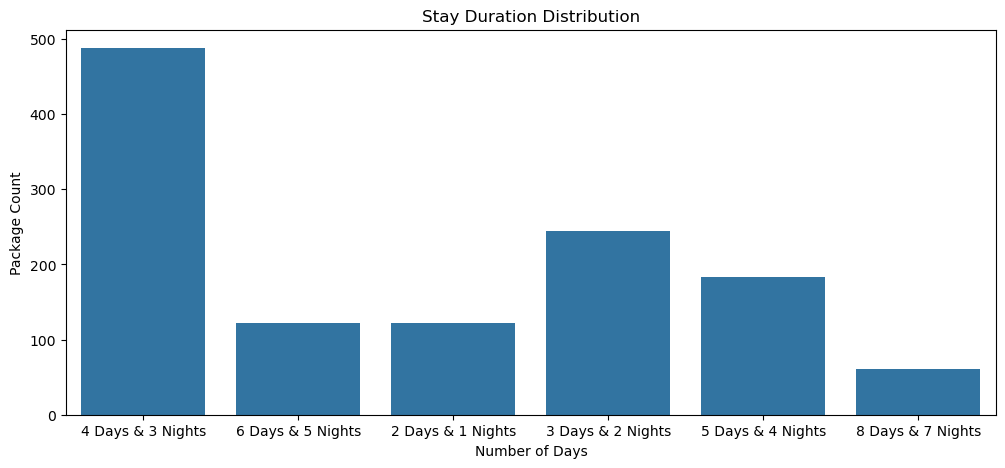

In [54]:
plt.figure(figsize=(12,5))
sns.countplot(x='Stay', data=df)

plt.title("Stay Duration Distribution")
plt.xlabel("Number of Days")
plt.ylabel("Package Count")
plt.show()

##### Interpretation
Most packages offer 4–5 day stays.

##### Business Insight
Short trips dominate tourism packages because they are more affordable and convenient.

###  Univariate Analysis - Categorical Variable 

#### 1.6 Bar Plot - Top Destinations

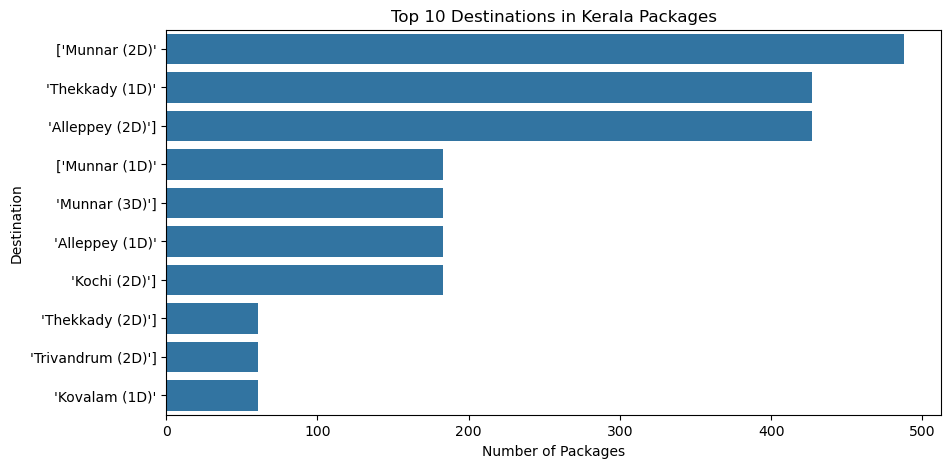

In [55]:
destinations = df['Location'].str.split(',')

dest_df = destinations.explode()

dest_df = dest_df.str.strip()

top_dest = dest_df.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_dest.values, y=top_dest.index)

plt.title("Top 10 Destinations in Kerala Packages")
plt.xlabel("Number of Packages")
plt.ylabel("Destination")
plt.show()

##### Interpretation

The distribution shows that certain destinations like Munnar, Alleppey, and Thekkady appear more frequently in tour packages, indicating their popularity among travelers.

##### Business Insight

Travel companies focus on high-demand destinations to attract more customers and increase bookings. Promoting less common destinations can help diversify tourism and create niche travel packages.

#### 1.7 Pie Chart - Stay Duration Share

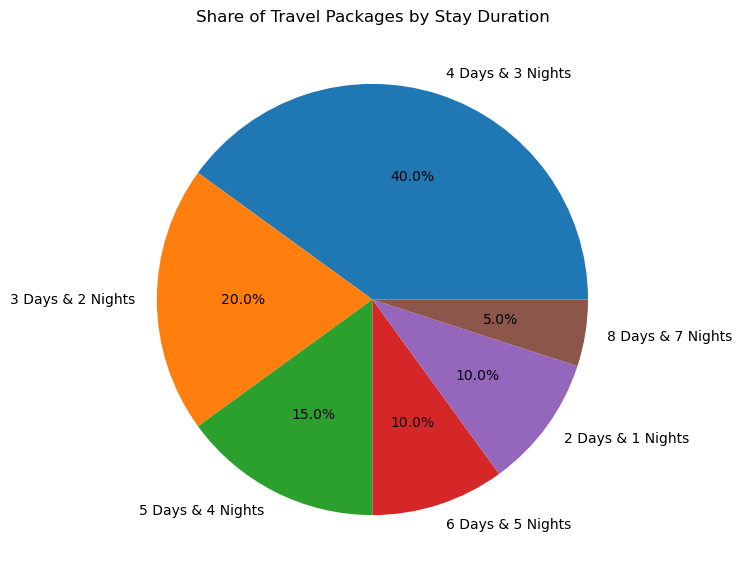

In [56]:
stay_counts = df['Stay'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(stay_counts, labels=stay_counts.index, autopct='%1.1f%%')

plt.title("Share of Travel Packages by Stay Duration")
plt.show()

##### Interpretation
4-day packages occupy the largest portion.

##### Business Insight
Travel agencies design packages based on short holiday travel patterns.

#### Univariate Insight

The univariate analysis reveals that most travel packages fall within a mid-range price category of ₹10,000–₹20,000. Discounts are generally moderate, typically between 10% and 25%. The majority of travel packages offer short stays of around 4–5 days, reflecting current travel trends. Popular destinations such as Munnar, Kochi, and Alleppey dominate the listings, indicating a strong preference for nature and scenic tourism experiences.

### 2.Bivariate Analysis

#### 2.1 Price vs Stay Duration - Scatter Plot

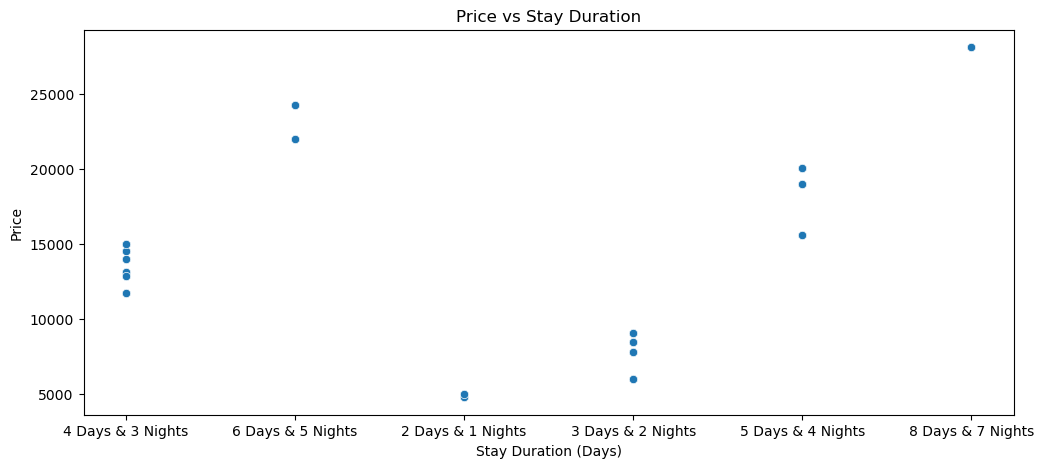

In [57]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Stay', y='Price', data=df)

plt.title("Price vs Stay Duration")
plt.xlabel("Stay Duration (Days)")
plt.ylabel("Price")
plt.show()

##### Interpretation
There is a positive trend where packages with longer stay durations tend to have higher prices.

##### Business Insight
Travel companies price packages based on number of days, meaning longer trips generate higher revenue.

#### 2.2 Stay Duration vs Price - Box Plot

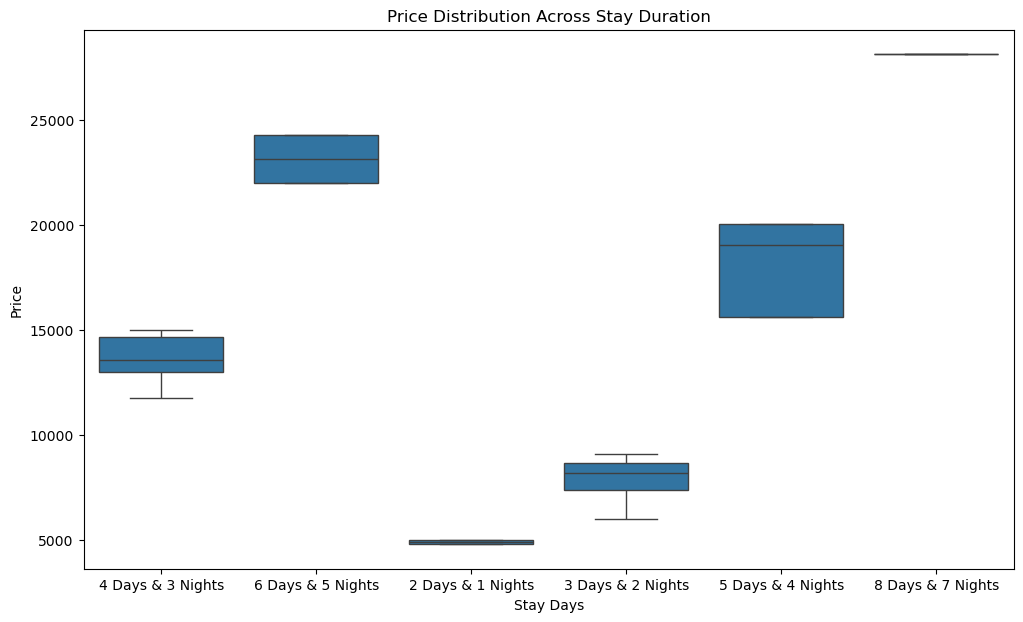

In [58]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Stay', y='Price', data=df)

plt.title("Price Distribution Across Stay Duration")
plt.xlabel("Stay Days")
plt.ylabel("Price")
plt.show()

##### Interpretation
As the stay duration increases, the median price also increases.

##### Business Insight
Travel agencies design longer stay packages with premium pricing structures.

#### 2.3 Packages vs Price - Box Plot

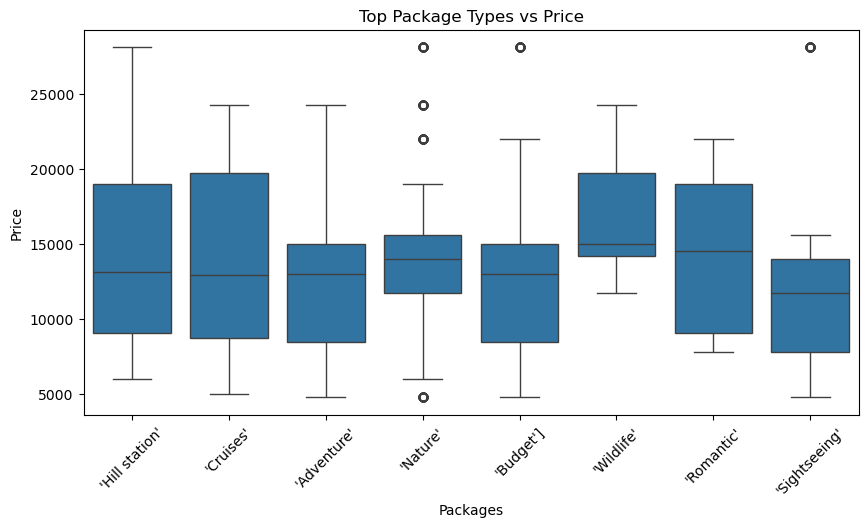

In [59]:
# Split and explode packages
pkg = df['Packages'].str.split(',')
pkg_df = df.assign(Packages=pkg).explode('Packages')
pkg_df['Packages'] = pkg_df['Packages'].str.strip()

# Select top 8 most common packages
top_pkg = pkg_df['Packages'].value_counts().head(8).index

filtered_pkg = pkg_df[pkg_df['Packages'].isin(top_pkg)]

plt.figure(figsize=(10,5))
sns.boxplot(x='Packages', y='Price', data=filtered_pkg)

plt.xticks(rotation=45)
plt.title("Top Package Types vs Price")
plt.show()

##### Interpretation

Different package categories show different price ranges. Adventure and premium experiences tend to have higher price distributions.

##### Business Insight

Travel companies can price premium packages higher due to higher perceived value. Budget sightseeing packages can target price-sensitive travelers.

#### 2.4 Stay Duration vs Discount - Bar Plot

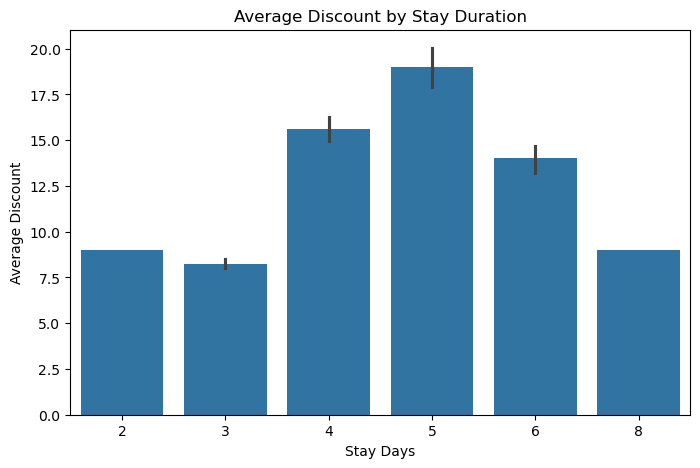

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(x='Days', y='Discount', data=df)

plt.title("Average Discount by Stay Duration")
plt.xlabel("Stay Days")
plt.ylabel("Average Discount")
plt.show()

##### Interpretation
Packages with more Days tend to have slightly higher discounts.

##### Business Insight
Longer packages offer more discounts to encourage customers to choose extended trips.

##### Bivariate Insight

Bivariate analysis was conducted to examine relationships between travel package attributes such as price, discount, and stay duration. The analysis revealed that travel package prices increase with longer stay durations. Additionally, higher-priced packages often provide larger discounts, indicating strategic pricing by travel companies to attract customers. The strong correlation between original price and final price confirms that discounts are applied proportionally across travel packages.

### 3.Multivariate Analysis

#### 3.1 Price vs Duration vs Discount - Scatter Plot

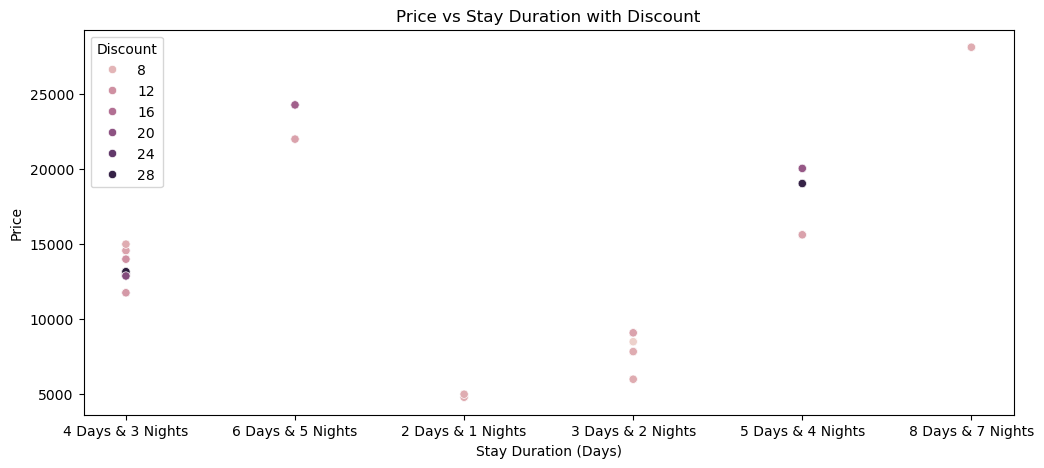

In [61]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Stay', y='Price', hue='Discount', data=df)

plt.title("Price vs Stay Duration with Discount")
plt.xlabel("Stay Duration (Days)")
plt.ylabel("Price")
plt.show()

##### Interpretation

Packages with longer stay durations tend to have higher prices, and higher discounts are often associated with higher-priced packages.

##### Business Insight

Travel companies use discount strategies to promote premium packages with longer stays.

#### 3.2 Relationship Between Multiple Numerical Variables - Pair Plot

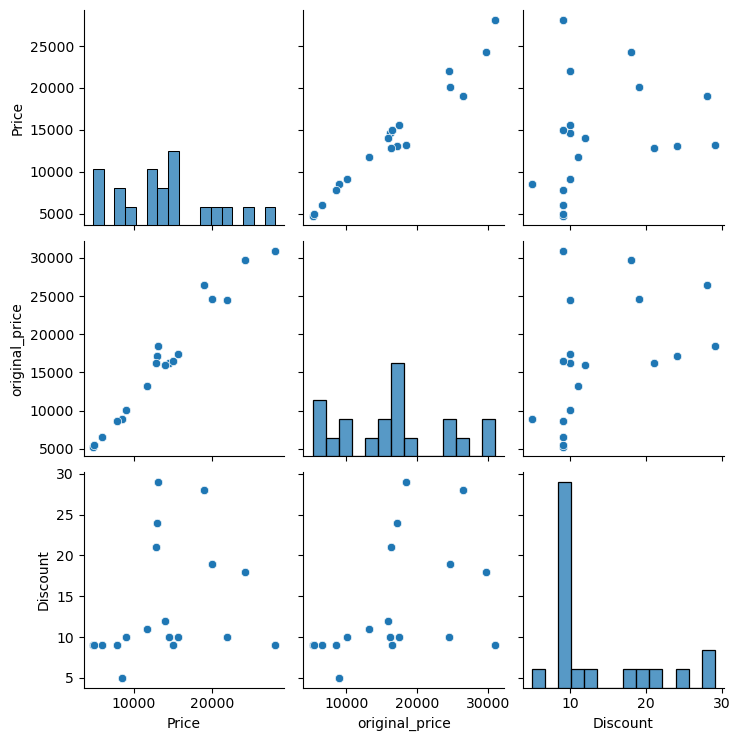

In [62]:
sns.pairplot(df[['Price','original_price','Discount','Stay']])
plt.show()

##### Interpretation
The pair plot shows relationships between all numerical variables simultaneously.

##### Business Insight
It helps identify strong correlations, such as the relationship between original price and final price.

#### 3.3 Heatmap (Correlation Matrix)

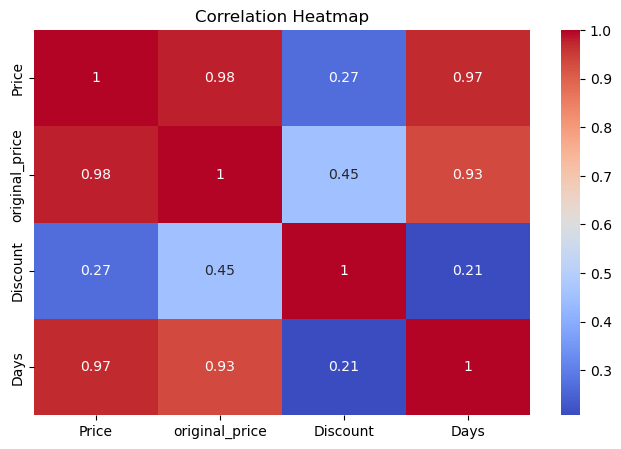

In [63]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Price','original_price','Discount','Days']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

##### Interpretation
- Strong positive correlation between original_price and price
- Weak correlation between discount and days

##### Business Insight
- Pricing is mainly influenced by base price rather than discount percentage

#### 4.3 Pivot Tables Analysis
Pivot tables help summarize business insights.

In [64]:
pivot_multi = pd.pivot_table(df,
                              values='Price',
                              index='Stay',
                              columns='Discount',
                              aggfunc='mean')

pivot_multi

Discount,5,9,10,11,12,18,19,21,24,28,29
Stay,,,,,,,,,,,
2 Days & 1 Nights,NaN,4900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3 Days & 2 Nights,8500.0,6920.0,9092.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4 Days & 3 Nights,NaN,15000.0,14571.0,11760.0,14000.0,NaN,NaN,12880.0,13020.0,NaN,13167.0
5 Days & 4 Nights,NaN,NaN,15624.0,NaN,NaN,NaN,20048.0,NaN,NaN,19040.0,NaN
6 Days & 5 Nights,NaN,NaN,22000.0,NaN,NaN,24279.0,NaN,NaN,NaN,NaN,NaN
8 Days & 7 Nights,NaN,28123.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Interpretation
This table shows the average price of packages for different stay durations and discount percentages.

##### Business Insight
Packages with longer stay durations and higher discounts often have higher prices, indicating promotional pricing for premium trips.

## Key Insights from Analysis
Most travel packages are priced between ₹10,000–₹20,000, targeting budget and mid-range travelers.

- 4–5 day trips are the most common, showing a preference for short vacations.
- Higher-priced packages often provide larger discounts to attract customers.
-  Destinations like Munnar, Kochi, and Alleppey are the most popular in travel packages.
- Longer stay durations lead to higher package prices, indicating pricing based on trip length.

# Final Conclusion 

Travel package data was scraped from the TravelTriangle website and analyzed using exploratory data analysis techniques. The analysis showed that most travel packages fall in the mid-price range and offer short-duration trips of around 4–5 days. Popular destinations such as Munnar, Kochi, and Alleppey appear frequently in travel packages. Discounts are commonly used, especially for higher-priced packages, indicating strategic pricing by travel companies.

## Business Recommendations
- Travel companies can create more mid-budget packages with flexible durations to attract a wider audience.
- Offering seasonal promotions or bundled experiences for premium packages may increase bookings.
- Expanding packages to less explored destinations could help reduce competition and attract new travelers.